<a href="https://colab.research.google.com/github/nttqyn/Project-III/blob/main/final_igtd_fewshot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from scipy.spatial.distance import pdist, squareform
import time
import random
import warnings
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import os

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 1. Tiền xử lý dữ liệu

**Mục tiêu:**
* Làm sạch dữ liệu NSL-KDD
* Chuyển đổi nhãn tấn công về các nhóm chính
* Mã hóa dữ liệu định danh (categorical) sang số
* Chuẩn hóa giá trị về khoảng [0;1]


In [ ]:
# Ánh xạ Nhãn
ATTACK_MAPPING = {
    'normal': 0,

    # DoS (Denial of Service)
    'neptune': 1, 'smurf': 1, 'pod': 1, 'teardrop': 1, 'land': 1, 'back': 1,
    'apache2': 1, 'udpstorm': 1, 'processtable': 1, 'worm': 1,
    'mailbomb': 1, 'snmpgetattack': 1,

    # Probe (Dò quét)
    'satan': 2, 'ipsweep': 2, 'nmap': 2, 'portsweep': 2, 'mscan': 2, 'saint': 2,

    # R2L (Remote to Local)
    'guess_passwd': 3, 'ftp_write': 3, 'imap': 3, 'phf': 3, 'multihop': 3,
    'warezmaster': 3, 'warezclient': 3, 'spy': 3,
    'snmpguess': 3, 'httptunnel': 3, 'named': 3, 'sendmail': 3, 'xlock': 3, 'xsnoop': 3,

    # U2R (User to Root)
    'buffer_overflow': 4, 'loadmodule': 4, 'perl': 4, 'rootkit': 4, 'ps': 4,
    'sqlattack': 4, 'xterm': 4
}

In [ ]:
def load_and_preprocess_data(train_path, test_path, test_21_path):
    # 1. Định nghĩa tên cột chuẩn NSL-KDD
    col_names = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
                 'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
                 'root_shell','su_attempted','num_root','num_file_creations','num_shells',
                 'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
                 'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
                 'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
                 'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
                 'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
                 'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
                 'label','level']

    # 2. Đọc dữ liệu
    train_df = pd.read_csv(train_path, names=col_names)
    test_df = pd.read_csv(test_path, names=col_names)
    test_21_df = pd.read_csv(test_21_path, names=col_names)

    # 3. Loại bỏ cột 'level' và cột 'num_outbound_cmds'
    drop_cols = ['level', 'num_outbound_cmds']
    train_df.drop(drop_cols, axis=1, inplace=True)
    test_df.drop(drop_cols, axis=1, inplace=True)
    test_21_df.drop(drop_cols, axis=1, inplace=True)

    # 4. Map nhãn tấn công
    train_df['label'] = train_df['label'].map(lambda x: ATTACK_MAPPING.get(x, -1))
    test_df['label'] = test_df['label'].map(lambda x: ATTACK_MAPPING.get(x, -1))
    test_21_df['label'] = test_21_df['label'].map(lambda x: ATTACK_MAPPING.get(x, -1))

    # 5. Lọc bỏ các nhãn không xác định (-1)
    train_df = train_df[train_df['label'] != -1]
    test_df = test_df[test_df['label'] != -1]
    test_21_df = test_21_df[test_21_df['label'] != -1]

    # 6. Tách nhãn (Label) và Đặc trưng (Features)
    y_train = train_df.pop('label').values
    y_test = test_df.pop('label').values
    y_test_21 = test_21_df.pop('label').values

    # 7. Mã hóa Label Encoding cho các cột phân loại
    categorical_cols = ['protocol_type', 'service', 'flag']
    for col in categorical_cols:
        le = LabelEncoder()
        combined = pd.concat([train_df[col], test_df[col], test_21_df[col]], axis=0).astype(str)
        le.fit(combined)

        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))
        test_21_df[col] = le.transform(test_21_df[col].astype(str))

    # 8. Chuẩn hóa với QuantileTransformer
    scaler = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
    X_train = scaler.fit_transform(train_df)
    X_test = scaler.transform(test_df)
    X_test_21 = scaler.transform(test_21_df)

    print(f" - Train shape: {X_train.shape}")
    print(f" - Test shape: {X_test.shape}")
    print(f" - Test-21 shape: {X_test_21.shape}")

    return X_train, y_train, X_test, y_test, X_test_21, y_test_21

In [ ]:
 X_train, y_train, X_test, y_test, X_test_21, y_test_21 = load_and_preprocess_data(
    "../input/nslkdd/KDDTrain+.txt",
    "../input/nslkdd/KDDTest+.txt",
    "../input/nslkdd/KDDTest-21.txt" )

 - Train shape: (125973, 40)
 - Test shape: (22544, 40)
 - Test-21 shape: (11850, 40)


# 2. Chuyển đổi dữ liệu dạng bảng sang ảnh (IGTD)

**Mục tiêu**: Sắp xếp lại các đặc trưng (features) đã tiền xử lý lên một lưới 2D sao cho các đặc trưng tương đồng nằm cạnh nhau

Do sau khi xử lý NSL-KDD có 40 đặc trưng => Xây dựng ảnh 7x7 (49 đặc trưng) => cần padding, thêm 9 đặc trưng giả có giá trị bằng 0. Việc padding 0 đảm bảo giữ nguyên thông tin của các đặc trưng ban đầu và không gây nhiễu cho mô hình học sâu.

In [ ]:
def get_igtd_permutation(X_train_processed, grid_size=7, max_iter=20000):
    N_samples, N_features = X_train_processed.shape
    target_pixels = grid_size * grid_size

    # 1. Padding dữ liệu nếu số feature < số pixel
    if N_features < target_pixels:
        padding = np.zeros((N_samples, target_pixels - N_features))
        X_padded = np.hstack([X_train_processed, padding])
    else:
        X_padded = X_train_processed[:, :target_pixels]

    # Thêm epsilon nhỏ để tránh lỗi chia cho 0 khi tính correlation (với các cột padding toàn 0)
    X_safe = X_padded.T + 1e-8

    # Tính khoảng cách Correlation (Distance = 1 - r)
    # range từ 0 (giống hệt) đến 2 (ngược chiều hoàn toàn)
    dist_vec = pdist(X_safe, metric='correlation')

    # Thay thế các giá trị NaN (nếu có) bằng 2.0 (khoảng cách lớn nhất)
    # Việc này giúp đẩy các pixel rác/padding ra xa các pixel đặc trưng có nghĩa
    dist_vec = np.nan_to_num(dist_vec, nan=2.0)

    # Chuyển về ma trận vuông
    dist_features = squareform(dist_vec)


    # Tính Rank ma trận đặc trưng
    R = dist_features.argsort().argsort().astype(float)

    # Tạo tọa độ pixel và tính khoảng cách vật lý
    coords = np.array([[i, j] for i in range(grid_size) for j in range(grid_size)])
    dist_pixels = squareform(pdist(coords, metric='euclidean'))

    # Tính Rank ma trận pixel
    Q = dist_pixels.argsort().argsort().astype(float)

    # Khởi tạo
    curr_indices = np.arange(target_pixels)
    h = np.full(target_pixels, -np.inf) # Lưu lịch sử iter cập nhật cuối cùng

    print("Bắt đầu tối ưu hóa IGTD (Swapping) với Correlation Metric...")
    start = time.time()

    # Vòng lặp tối ưu hóa (Swapping)
    for s in range(max_iter):
        # Chọn pixel chưa được cập nhật lâu nhất
        n_star = np.argmin(h)
        h[n_star] = s

        best_l, max_gain = -1, 0

        # Tìm vị trí l để swap với n_star sao cho gain lớn nhất
        for l in range(target_pixels):
            if l == n_star: continue

            # Tính độ lỗi giảm đi nếu đổi chỗ
            # Công thức: Error = tổng chênh lệch rank
            # Gain dương nghĩa là Error giảm

            err_before = (np.abs(R[n_star] - Q[n_star]).sum() + np.abs(R[l] - Q[l]).sum())

            # Tính error sau khi swap (giả định R đã swap hàng/cột n_star và l)
            # Vì Q cố định, ta so sánh hàng R[l] ở vị trí n_star và R[n_star] ở vị trí l
            err_after = (np.abs(R[l] - Q[n_star]).sum() + np.abs(R[n_star] - Q[l]).sum())

            gain = err_before - err_after

            if gain > max_gain:
                max_gain, best_l = gain, l

        # Thực hiện Swap nếu tìm được gain dương
        if max_gain > 0:
            # Swap trong ma trận khoảng cách đặc trưng R
            R[[n_star, best_l], :] = R[[best_l, n_star], :]
            R[:, [n_star, best_l]] = R[:, [best_l, n_star]]

            # Cập nhật chỉ số ánh xạ
            curr_indices[n_star], curr_indices[best_l] = curr_indices[best_l], curr_indices[n_star]

            h[best_l] = s

    print(f"Hoàn tất IGTD trong {time.time()-start:.2f}s")
    return curr_indices, target_pixels

In [ ]:
igtd_indices, total_p = get_igtd_permutation(X_train, grid_size=7, max_iter=30000)

Bắt đầu tối ưu hóa IGTD (Swapping) với Correlation Metric...
Hoàn tất IGTD trong 20.86s


In [ ]:
def transform_to_images(X_data, indices, grid_size=7):
    N_samples, N_features = X_data.shape
    target = grid_size * grid_size

    if N_features < target:
        padding = np.zeros((N_samples, target - N_features))
        X_padded = np.hstack([X_data, padding])
    else:
        X_padded = X_data

    X_ordered = X_padded[:, indices]
    X_images = X_ordered.reshape(-1, 1, grid_size, grid_size)

    return X_images

X_train_imgs = transform_to_images(X_train, igtd_indices)
X_test_imgs  = transform_to_images(X_test, igtd_indices)

print(f"Kích thước X_train_imgs: {X_train_imgs.shape}")

Kích thước X_train_imgs: (125973, 1, 7, 7)


In [ ]:
from torch.utils.data import TensorDataset

X_train_tensor = torch.tensor(X_train_imgs, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_imgs, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
def get_class_indices(dataset):
    """Gom nhóm các index theo nhãn để lấy mẫu """
    class_indices = {}
    for i in range(len(dataset)):
        _, label = dataset[i]
        l = label.item()
        if l not in class_indices:
            class_indices[l] = []
        class_indices[l].append(i)
    return class_indices

train_class_indices = get_class_indices(train_ds)
test_class_indices = get_class_indices(test_ds)

# 3. Xây dựng kiến trúc mô hình


### Kiến trúc mạng Backbone DSC-CNN
:Sử dụng Tích chập tách rời theo chiều sâu (Depthwise Separable Convolution - DSC) để giảm chi phí tính toán, phù hợp với môi trường Federated Learning và thiết bị biên.
- **Input:** Ảnh 7x7
- **Backbone:** 2 lớp DSC Block
- **Embedding:** Vector 128 chiều

In [ ]:
class DSC_Block(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        # Depthwise: Học đặc trưng không gian
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size=kernel_size,
                                   padding=kernel_size//2, groups=in_ch)
        # Pointwise: Kết hợp thông tin kênh
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.pointwise(self.depthwise(x))))

class DSC_CNN_NIDS(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            DSC_Block(1, 64, kernel_size=3), # Lớp 1: 7x7 -> 7x7
            nn.MaxPool2d(2),                 # 7x7 -> 3x3
            DSC_Block(64, 128, kernel_size=3),# Lớp 2: 3x3 -> 3x3
            nn.AdaptiveAvgPool2d((1, 1))     # Global Pooling về kích thước 1x1
        )
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.3)
        self.embedding = nn.Linear(128, 128)  # Vector nhúng 128 chiều

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        return self.embedding(x)

# 4. Chiến lược huấn luyện lai

### Hàm tạo Episode (N-way K-shot Sampling)
Hàm hỗ trợ lấy mẫu ngẫu nhiên từ dữ liệu để tạo thành các tập Support Set và Query Set cho mỗi vòng huấn luyện/kiểm thử.

In [ ]:
def create_episode_optimized(X_imgs, y, k_shot, q_query, n_way):
    unique_classes = np.unique(y)

    actual_n_way = min(len(unique_classes), n_way)

    # Chọn ngẫu nhiên các lớp cho episode này
    sampled_classes = random.sample(list(unique_classes), actual_n_way)

    support_images = []
    support_labels = []
    query_images = []
    query_labels = []

    for idx_cls, cls in enumerate(sampled_classes):
        all_idx = np.where(y == cls)[0]

        if len(all_idx) >= k_shot + q_query:
            sampled_indices = random.sample(list(all_idx), k_shot + q_query)
            support_idx = sampled_indices[:k_shot]
            query_idx = sampled_indices[k_shot:]
        else:
            support_idx = random.choices(all_idx, k=k_shot)
            remaining = list(set(all_idx) - set(support_idx))
            if len(remaining) > 0:
                query_idx = random.choices(remaining, k=q_query)
            else:
                query_idx = random.choices(all_idx, k=q_query)

        for idx in support_idx:
            support_images.append(X_imgs[idx])
            support_labels.append(idx_cls)

        for idx in query_idx:
            query_images.append(X_imgs[idx])
            query_labels.append(idx_cls)

    s_imgs = torch.tensor(np.stack(support_images), dtype=torch.float32)
    q_imgs = torch.tensor(np.stack(query_images), dtype=torch.float32)

    s_labs = torch.tensor(np.array(support_labels), dtype=torch.long)
    q_labs = torch.tensor(np.array(query_labels), dtype=torch.long)

    return s_imgs, s_labs, q_imgs, q_labs

### Giai đoạn 1: Pre-training (Học đại diện)
* Sử dụng **Triplet Loss** để xây dựng không gian nhúng cơ bản, tách biệt các cụm dữ liệu lớn (Normal, DoS, Probe).

In [ ]:
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        dist_pos = (anchor - positive).pow(2).sum(1)
        dist_neg = (anchor - negative).pow(2).sum(1)
        loss = F.relu(dist_pos - dist_neg + self.margin)
        return loss.mean()

class TripletIGTDDataset(Dataset):
    def __init__(self, X_imgs, y_labels):
        self.X = X_imgs
        self.y = y_labels
        self.classes = np.unique(y_labels)
        self.class_indices = {c: np.where(y_labels == c)[0] for c in self.classes}

        self.normal_label = 0

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        anchor_img = self.X[index]
        anchor_label = self.y[index]

        # --- 1. POSITIVE ---
        pos_idx = random.choice(self.class_indices[anchor_label])
        pos_img = self.X[pos_idx]

        # --- 2. NEGATIVE
        if anchor_label == self.normal_label:
            # Nếu Anchor là Normal, chọn Negative là một loại tấn công bất kỳ
            neg_label = random.choice([c for c in self.classes if c != self.normal_label])
        else:
            # Nếu Anchor là Tấn công, ưu tiên chọn Negative là Normal
            if random.random() < 0.7: # 70% chọn Normal làm Negative để đẩy tấn công ra xa
                neg_label = self.normal_label
            else: # 30% chọn lớp tấn công khác để phân tách các loại tấn công
                other_attacks = [c for c in self.classes if c != anchor_label and c != self.normal_label]
                neg_label = random.choice(other_attacks) if other_attacks else self.normal_label

        neg_idx = random.choice(self.class_indices[neg_label])
        neg_img = self.X[neg_idx]

        return (torch.tensor(anchor_img, dtype=torch.float32),
                torch.tensor(pos_img, dtype=torch.float32),
                torch.tensor(neg_img, dtype=torch.float32))

In [ ]:
# HÀM PRE-TRAIN ---
def pretrain_backbone_triplet(X_data, y_data, epochs=10, batch_size=128, lr=0.001):
    print(f"\n [PHASE 1] Pre-training Backbone với Triplet Loss...")
    model = DSC_CNN_NIDS().to(device)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = TripletLoss(margin=2.0)

    triplet_ds = TripletIGTDDataset(X_data, y_data)
    triplet_loader = DataLoader(triplet_ds, batch_size=batch_size, shuffle=True)

    for ep in range(epochs):
        total_loss = 0
        for anchor, pos, neg in triplet_loader:
            anchor, pos, neg = anchor.to(device), pos.to(device), neg.to(device)
            optimizer.zero_grad()

            embed_a = F.normalize(model(anchor), p=2, dim=1)
            embed_p = F.normalize(model(pos), p=2, dim=1)
            embed_n = F.normalize(model(neg), p=2, dim=1)

            loss = criterion(embed_a, embed_p, embed_n)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"   Epoch {ep+1}/{epochs} | Triplet Loss: {total_loss/len(triplet_loader):.4f}")
    return model

### Giai đoạn 2: Few-shot Learning với Focal Loss
* Tinh chỉnh mô hình (Fine-tuning) theo cơ chế Episode-based (N-way K-shot).
* Sử dụng **Focal Loss** với trọng số cao cho các lớp hiếm (U2R, R2L) để khắc phục mất cân bằng dữ liệu.
* Prototype
* Độ đo: Euclide

In [ ]:
def get_prototypical_scores(q_embeds, s_embeds, s_labs, n_way):
    prototypes = []
    for i in range(n_way):
        mask = (s_labs == i)
        if mask.sum() > 0:
            proto = s_embeds[mask].mean(dim=0)
        else:
            proto = torch.zeros_like(s_embeds[0])
        prototypes.append(proto)

    prototypes = torch.stack(prototypes)

    # Tính bình phương khoảng cách Euclidean
    # Trả về giá trị âm vì hàm Loss cần Score cao cho khoảng cách thấp
    dists = torch.cdist(q_embeds, prototypes, p=2)
    return -(dists**2)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

In [ ]:
def train_finetune_loop(pretrained_model, X_input, y_input, n_episodes=2000, n_way=5, k_shot=20, q_query=15, lr=0.00005):
    model = pretrained_model
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Trọng số thưởng phạt
    class_weights = torch.tensor([0.3, 1.0, 1.0, 60.0, 40.0]).to(device)

    # Khởi tạo Focal Loss
    criterion = FocalLoss(gamma=2.5, weight=class_weights)

    DISTANCE_SCALE = 0.5

    print(f"\n [PHASE 2] Fine-tuning với Focal Loss & Euclidean Distance...")

    for ep in range(n_episodes):
        # Lấy mẫu episode từ dữ liệu
        s_imgs, s_labs, q_imgs, q_labs = create_episode_optimized(X_input, y_input, k_shot, q_query, n_way)
        s_imgs, s_labs, q_imgs, q_labs = s_imgs.to(device), s_labs.to(device), q_imgs.to(device), q_labs.to(device)

        optimizer.zero_grad()

        # Trích xuất vector đặc trưng
        s_embeds = model(s_imgs)
        q_embeds = model(q_imgs)

        # Euclidean Distance Scores
        scores = get_prototypical_scores(q_embeds, s_embeds, s_labs, n_way)

        # Focal Loss
        loss = criterion(scores * DISTANCE_SCALE, q_labs)

        loss.backward()
        optimizer.step()

        if (ep + 1) % 500 == 0:
            print(f"   Episode {ep+1}/{n_episodes} | Focal Loss: {loss.item():.6f}")

    return model

# 5. Thực thi Model

In [ ]:
# --- MAIN ---
# 1. Tách dữ liệu Base (Normal, DoS, Probe) để Pretrain
print("🔄 Chuẩn bị dữ liệu...")
base_mask = y_train <= 2
X_base = X_train_imgs[base_mask]
y_base = y_train[base_mask]

# 2.  PHASE 1: Pre-training
pretrained_model = pretrain_backbone_triplet(X_base, y_base, epochs=5, batch_size=128)

# 3.  PHASE 2: Fine-tuning
final_model = train_finetune_loop(
    pretrained_model,
    X_train_imgs, y_train,
    n_episodes=5000,
    n_way=5, k_shot=20, q_query=15
)

🔄 Chuẩn bị dữ liệu...

 [PHASE 1] Pre-training Backbone với Triplet Loss...
   Epoch 1/5 | Triplet Loss: 0.1903
   Epoch 2/5 | Triplet Loss: 0.0604
   Epoch 3/5 | Triplet Loss: 0.0444
   Epoch 4/5 | Triplet Loss: 0.0392
   Epoch 5/5 | Triplet Loss: 0.0344

 [PHASE 2] Fine-tuning với Focal Loss & Euclidean Distance...
   Episode 500/5000 | Focal Loss: 9.714271
   Episode 1000/5000 | Focal Loss: 1.745460
   Episode 1500/5000 | Focal Loss: 0.402585
   Episode 2000/5000 | Focal Loss: 3.141324
   Episode 2500/5000 | Focal Loss: 1.850111
   Episode 3000/5000 | Focal Loss: 2.360855
   Episode 3500/5000 | Focal Loss: 0.461968
   Episode 4000/5000 | Focal Loss: 6.416490
   Episode 4500/5000 | Focal Loss: 1.055376
   Episode 5000/5000 | Focal Loss: 0.550082


# 6. Kết quả và Đánh giá

### 6.1. Bộ trích xuất đặc trưng (Kết quả IGTD và Không gian nhúng)
* Trực quan hóa dữ liệu sau khi chuyển đổi sang dạng ảnh và phân bố không gian đặc trưng (t-SNE).

**Minh họa dữ liệu được chuyển thành ảnh 7x7**

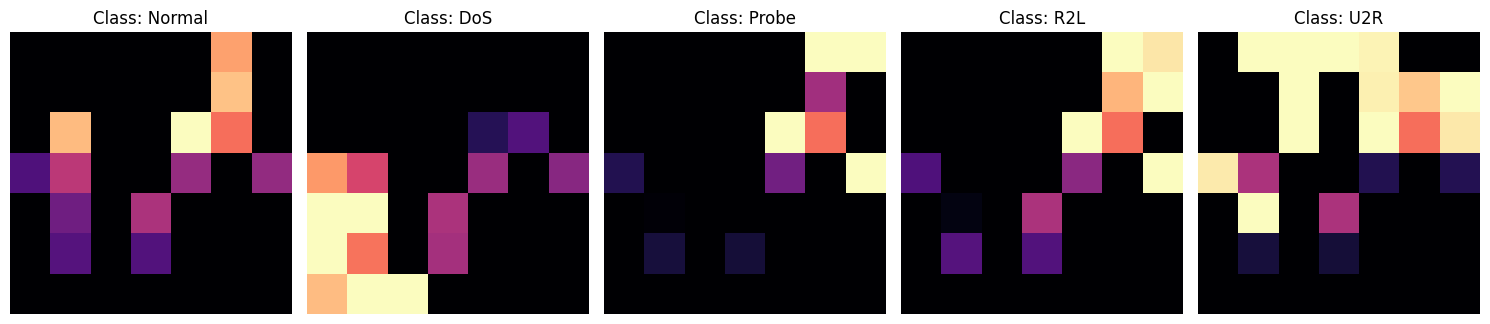

In [ ]:
import matplotlib.pyplot as plt

def visualize_igtd_samples(dataset, class_indices, class_names):
    plt.figure(figsize=(15, 5))
    for i, class_label in enumerate(range(5)):
        idx = class_indices[class_label][0]
        img, label = dataset[idx]

        plt.subplot(1, 5, i+1)

        plt.imshow(img.squeeze().numpy(), cmap='magma')
        plt.title(f"Class: {class_names[class_label]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

class_names = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
visualize_igtd_samples(train_ds, train_class_indices, class_names)

**Vị trị các đặc trưng trên lưới ánh sau khi áp dụng thuật toán IGTD**

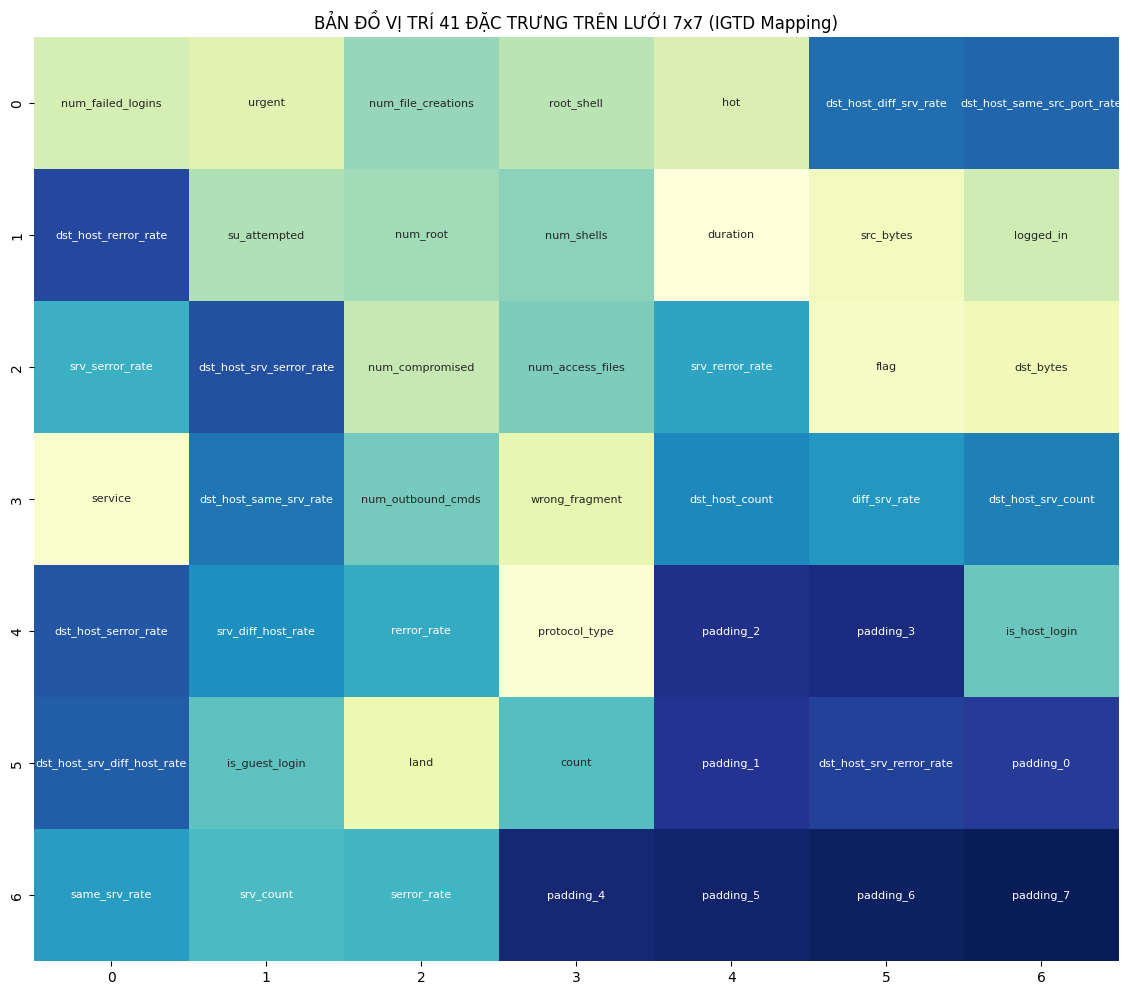

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lấy danh sách tên 41 đặc trưng
feat_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate'
]

full_feat_names = feat_names + [f"padding_{i}" for i in range(49 - len(feat_names))]

def show_feature_location_map(indices, names):
    grid_labels = np.full((7, 7), "", dtype=object)
    grid_values = np.zeros((7, 7))

    # igtd_indices[k] = j có nghĩa là đặc trưng thứ j sẽ nằm ở vị trí k trên ảnh phẳng
    # Vị trí k tương ứng với tọa độ (k // 7, k % 7)
    for k, feat_idx in enumerate(indices):
        row, col = k // 7, k % 7
        grid_labels[row, col] = names[feat_idx]
        grid_values[row, col] = feat_idx

    plt.figure(figsize=(14, 12))
    sns.heatmap(grid_values, annot=grid_labels, fmt="", cmap="YlGnBu",
                cbar=False, annot_kws={"size": 8})
    plt.title("BẢN ĐỒ VỊ TRÍ 41 ĐẶC TRƯNG TRÊN LƯỚI 7x7 (IGTD Mapping)")
    plt.show()

show_feature_location_map(igtd_indices, full_feat_names)

**Đánh giá mức ảnh hưởng các đặc trưng khi so sánh từng lớp tấn công và lớp bình thường**

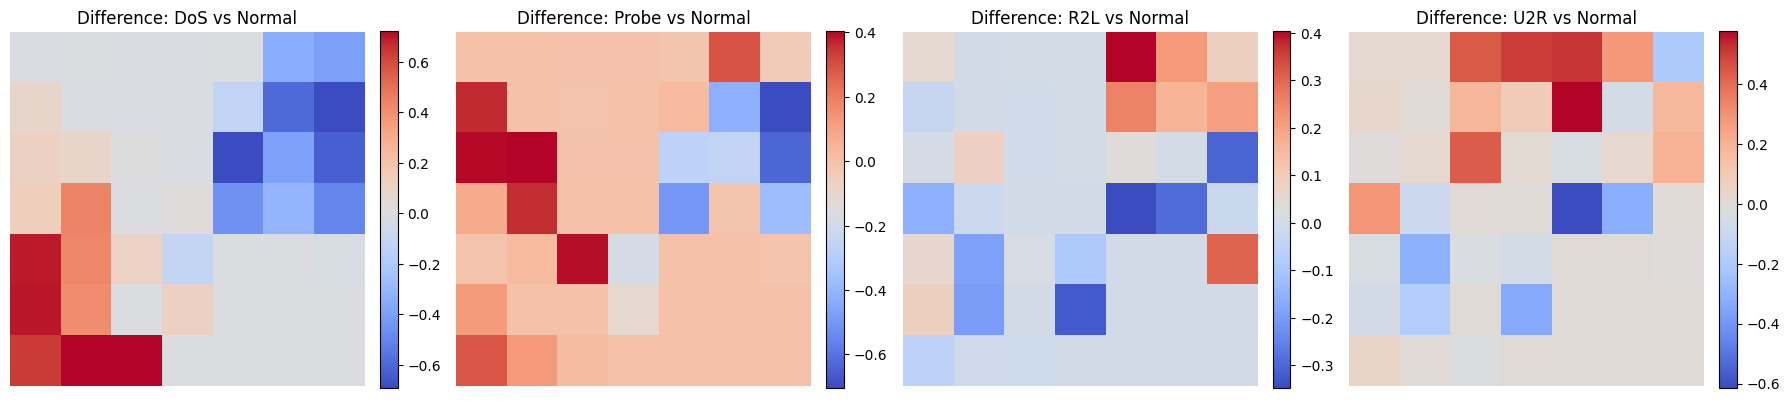

In [ ]:
class_names_list = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
def plot_difference_maps(X, y, class_names):
    normal_idx = np.where(y == 0)[0]
    normal_mean = np.mean(X[normal_idx], axis=0).reshape(7, 7)

    plt.figure(figsize=(18, 4))
    for i in range(1, 5):
        idx = np.where(y == i)[0]
        attack_mean = np.mean(X[idx], axis=0).reshape(7, 7)

        diff = attack_mean - normal_mean

        plt.subplot(1, 4, i)
        plt.imshow(diff, cmap='coolwarm')
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.title(f"Difference: {class_names[i]} vs Normal")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_difference_maps(X_train_imgs, y_train, class_names_list)

**Trực quan hóa phân bố không gian đặc trưng**

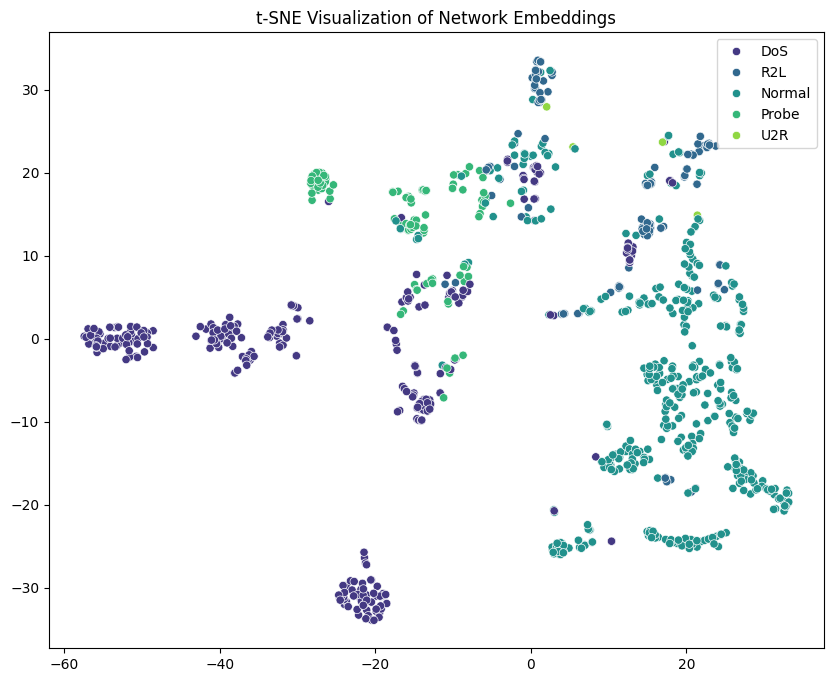

In [ ]:
from sklearn.manifold import TSNE

def plot_tsne(model, dataset, n_samples=1000):
    model.eval()
    loader = DataLoader(dataset, batch_size=n_samples, shuffle=True)
    images, labels = next(iter(loader))

    with torch.no_grad():
        embeddings = model(images.to(device)).cpu().numpy()

    tsne = TSNE(n_components=2, perplexity=30)
    low_dim_embed = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=low_dim_embed[:,0], y=low_dim_embed[:,1],
                    hue=[class_names[l.item()] for l in labels], palette='viridis')
    plt.title("t-SNE Visualization of Network Embeddings")
    plt.show()

plot_tsne(final_model, test_ds)

### 6.2. Kịch bản kiểm thử

**Chuẩn bị tập Test-21**

In [ ]:
X_test_21_imgs = transform_to_images(X_test_21, igtd_indices)

X_test_21_tensor = torch.tensor(X_test_21_imgs, dtype=torch.float32)
y_test_21_tensor = torch.tensor(y_test_21, dtype=torch.long)
test_21_ds = TensorDataset(X_test_21_tensor, y_test_21_tensor)

test_21_class_indices = get_class_indices(test_21_ds)

print("Tập Test-21 (Khó) sẵn sàng!")

Tập Test-21 (Khó) sẵn sàng!


In [ ]:
def create_test_episode(support_ds, support_indices, query_ds, query_indices, n_way=5, k_shot=20, q_query=15):
    support_images, support_labels = [], []
    query_images, query_labels = [], []

    sampled_classes = list(range(n_way))

    for i, cls in enumerate(sampled_classes):
        # --- Lấy Support Set ---
        # Kiểm tra xem lớp cls có trong tập support không
        if cls in support_indices:
            s_idx_list = support_indices[cls]
            # Nếu số lượng mẫu ít hơn k_shot, lấy tất cả hoặc lấy lặp lại
            if len(s_idx_list) < k_shot:
                s_idx = random.choices(s_idx_list, k=k_shot)
            else:
                s_idx = random.sample(s_idx_list, k_shot)

            for idx in s_idx:
                img, _ = support_ds[idx]
                support_images.append(img)
                support_labels.append(i)

        # --- Lấy Query Set ---
        if cls in query_indices:
            q_idx_list = query_indices[cls]
            n_q = min(len(q_idx_list), q_query)
            if n_q > 0:
                q_idx = random.sample(q_idx_list, n_q)
                for idx in q_idx:
                    img, _ = query_ds[idx]
                    query_images.append(img)
                    query_labels.append(i)

    return (torch.stack(support_images), torch.tensor(support_labels),
            torch.stack(query_images), torch.tensor(query_labels))

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (True)')
    plt.title('Confusion Matrix')
    plt.show()


### Thực hiện đánh giá trên 3 kịch bản:
1. **Train Set:** Kiểm tra khả năng hội tụ.
2. **Test+ Set:** Kiểm tra khả năng tổng quát hóa.
3. **Test-21 Set:** Kiểm tra độ bền vững trên các mẫu khó.

In [ ]:
def evaluate_dataset(model,
                     support_ds, support_indices,
                     query_ds, query_indices,
                     n_way=5, k_shot=20, q_query=15,
                     n_episodes=1000,
                     title="Đánh giá"):
    """
    - support_ds: Nguồn để lấy mẫu học (Tri thức)
    - query_ds: Nguồn để lấy mẫu kiểm tra (Cần đánh giá)
    """
    model.eval()
    all_preds = []
    all_targets = []
    class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

    print(f"\n [{title}] Đang chạy {n_episodes} episodes...")
    print(f"   ► Support (Học): {len(support_ds)} mẫu")
    print(f"   ► Query (Thi):   {len(query_ds)} mẫu")

    with torch.no_grad():
        for _ in range(n_episodes):
            s_imgs, s_labs, q_imgs, q_labs = create_test_episode(
                support_ds, support_indices,
                query_ds, query_indices,
                n_way=n_way, k_shot=k_shot, q_query=q_query
            )

            s_imgs = s_imgs.to(device)
            s_labs = s_labs.to(device)
            q_imgs = q_imgs.to(device)

            s_embeds = model(s_imgs)
            q_embeds = model(q_imgs)

            scores = get_prototypical_scores(q_embeds, s_embeds, s_labs, n_way)
            preds = torch.argmax(scores, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(q_labs.numpy())

    report = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True)

    # In báo cáo
    print("-" * 60)
    print(f"BÁO CÁO KẾT QUẢ: {title}")
    print("-" * 60)
    print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

    plot_confusion_matrix(all_targets, all_preds, class_names)

    return all_targets, all_preds


📊 [Kịch bản 1: TRAIN SET (Checking Fit)] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   125973 mẫu
------------------------------------------------------------
BÁO CÁO KẾT QUẢ: Kịch bản 1: TRAIN SET (Checking Fit)
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.9585    0.9224    0.9401     75000
         DoS     0.9973    0.9892    0.9932     75000
       Probe     0.9796    0.9828    0.9812     75000
         R2L     0.9512    0.9647    0.9579     75000
         U2R     0.9701    0.9975    0.9836     75000

    accuracy                         0.9713    375000
   macro avg     0.9713    0.9713    0.9712    375000
weighted avg     0.9713    0.9713    0.9712    375000



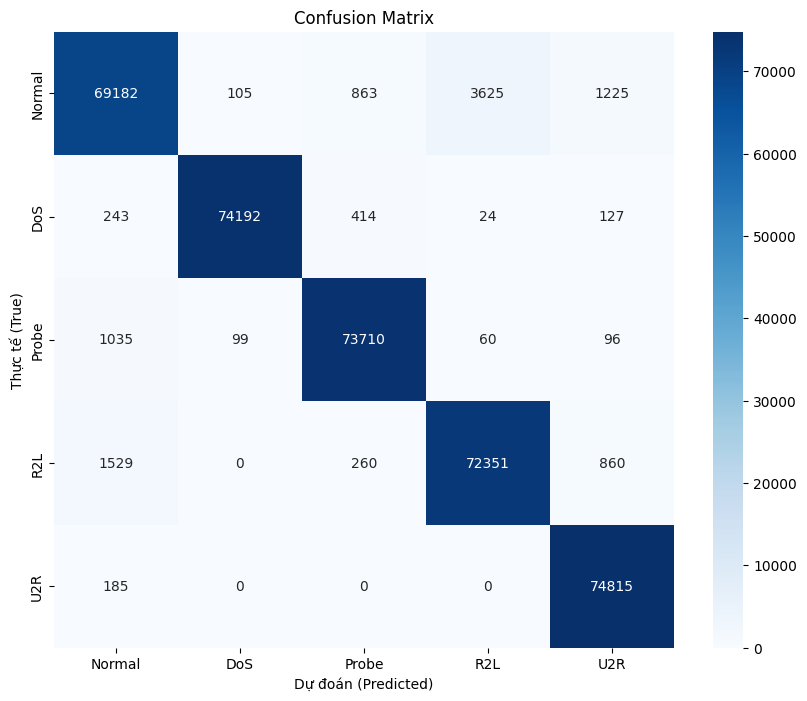


📊 [Kịch bản 2: TEST+ SET (Standard Eval)] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   22544 mẫu
------------------------------------------------------------
BÁO CÁO KẾT QUẢ: Kịch bản 2: TEST+ SET (Standard Eval)
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.4391    0.9486    0.6003     75000
         DoS     0.9173    0.7585    0.8304     75000
       Probe     0.8414    0.8064    0.8235     75000
         R2L     0.6410    0.2646    0.3745     75000
         U2R     0.9407    0.6035    0.7353     75000

    accuracy                         0.6763    375000
   macro avg     0.7559    0.6763    0.6728    375000
weighted avg     0.7559    0.6763    0.6728    375000



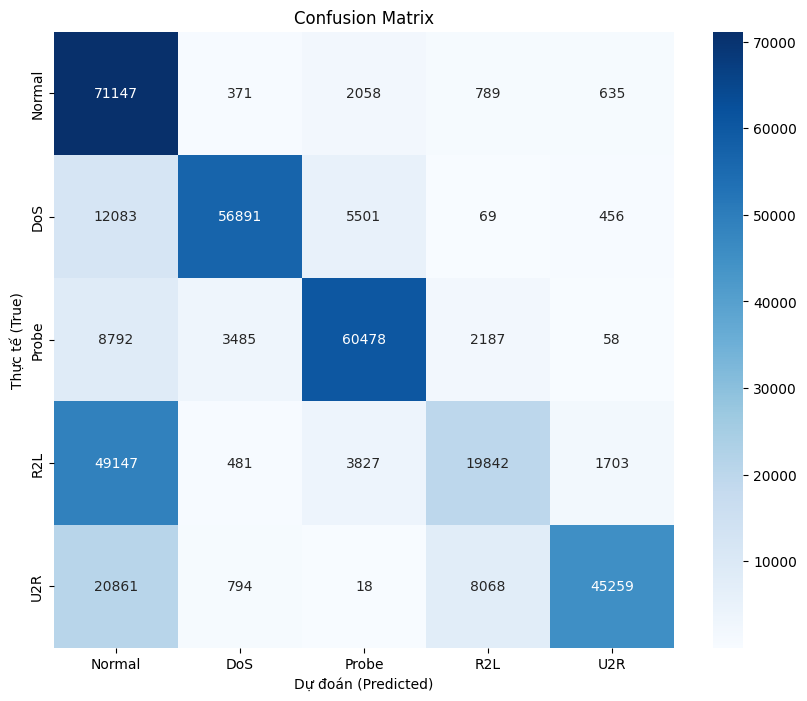


📊 [Kịch bản 3: TEST-21 SET (Hard Samples)] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   11850 mẫu
------------------------------------------------------------
BÁO CÁO KẾT QUẢ: Kịch bản 3: TEST-21 SET (Hard Samples)
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.3797    0.8095    0.5169     75000
         DoS     0.8760    0.6057    0.7162     75000
       Probe     0.7458    0.8040    0.7738     75000
         R2L     0.6145    0.2662    0.3715     75000
         U2R     0.9107    0.6060    0.7278     75000

    accuracy                         0.6183    375000
   macro avg     0.7053    0.6183    0.6212    375000
weighted avg     0.7053    0.6183    0.6212    375000



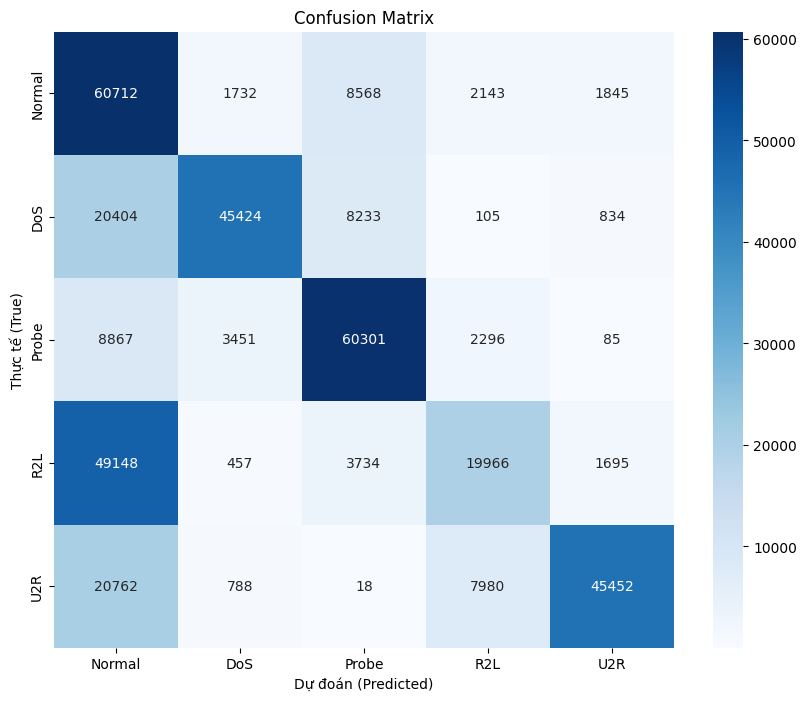

In [ ]:
# --- CHẠY ĐÁNH GIÁ 3 KỊCH BẢN ---

# CẤU HÌNH CHUNG
N_EVAL_EPISODES = 5000
K_SHOT = 20

# KỊCH BẢN 1: Train vs Train (Kiểm tra khả năng học/ghi nhớ)
# Support: Train | Query: Train
_ = evaluate_dataset(
    final_model,
    train_ds, train_class_indices,  # Học từ Train
    train_ds, train_class_indices,  # Thi trên Train
    n_episodes=N_EVAL_EPISODES, k_shot=K_SHOT,
    title="Kịch bản 1: TRAIN SET (Checking Fit)"
)

# KỊCH BẢN 2: Train vs Test+ (Kiểm tra khả năng tổng quát hóa chuẩn)
# Support: Train | Query: Test+
_ = evaluate_dataset(
    final_model,
    train_ds, train_class_indices,  # Học từ Train
    test_ds, test_class_indices,    # Thi trên Test+
    n_episodes=N_EVAL_EPISODES, k_shot=K_SHOT,
    title="Kịch bản 2: TEST+ SET (Standard Eval)"
)

# KỊCH BẢN 3: Train vs Test-21 (Kiểm tra độ bền vững trên mẫu khó)
# Support: Train | Query: Test-21
_ = evaluate_dataset(
    final_model,
    train_ds, train_class_indices,   # Học từ Train
    test_21_ds, test_21_class_indices, # Thi trên Test-21
    n_episodes=N_EVAL_EPISODES, k_shot=K_SHOT,
    title="Kịch bản 3: TEST-21 SET (Hard Samples)"
)

### Đánh giá sự ổn định (Stability Evaluation)
Thực hiện huấn luyện và kiểm thử lặp lại trên 5 seed ngẫu nhiên khác nhau để tính toán độ lệch chuẩn của mô hình.

🎲 5 Seed ngẫu nhiên được chọn cho thí nghiệm: [8473, 2796, 9930, 2856, 4250]
BẮT ĐẦU ĐÁNH GIÁ 5-SEED (5000 episodes/seed)...

--- 🏁 RUN 1/5 | SEED: 8473 ---

 [PHASE 1] Pre-training Backbone với Triplet Loss...
   Epoch 1/5 | Triplet Loss: 0.2221
   Epoch 2/5 | Triplet Loss: 0.0262
   Epoch 3/5 | Triplet Loss: 0.0102
   Epoch 4/5 | Triplet Loss: 0.0091
   Epoch 5/5 | Triplet Loss: 0.0220

 [PHASE 2] Fine-tuning với Focal Loss & Euclidean Distance...
   Episode 500/5000 | Focal Loss: 16.740101
   Episode 1000/5000 | Focal Loss: 8.316055
   Episode 1500/5000 | Focal Loss: 8.859174
   Episode 2000/5000 | Focal Loss: 4.965467
   Episode 2500/5000 | Focal Loss: 4.183149
   Episode 3000/5000 | Focal Loss: 1.739433
   Episode 3500/5000 | Focal Loss: 10.014675
   Episode 4000/5000 | Focal Loss: 2.162921
   Episode 4500/5000 | Focal Loss: 5.532913
   Episode 5000/5000 | Focal Loss: 2.413679

📊 [Seed 8473 - Test+] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   2254

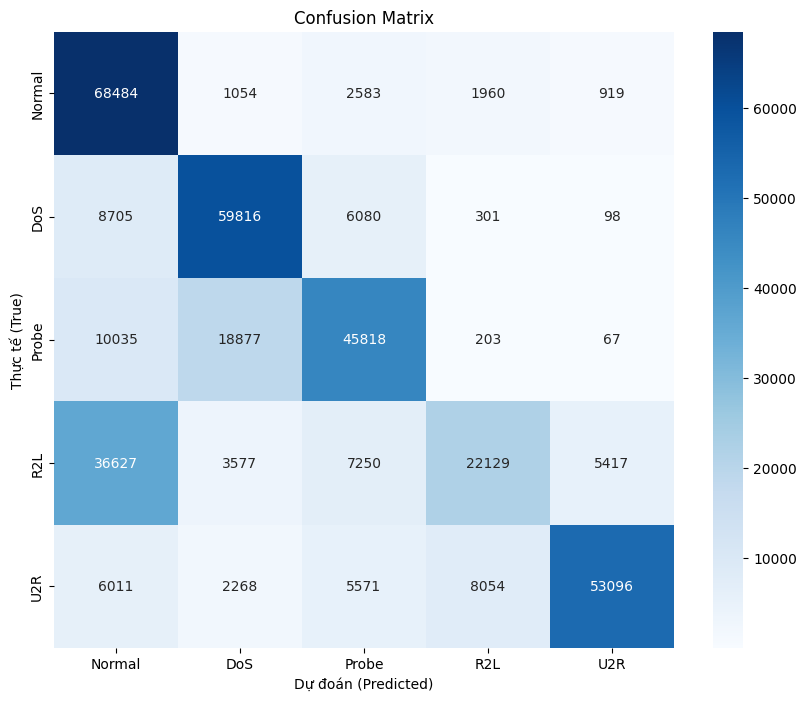


--- 🏁 RUN 2/5 | SEED: 2796 ---

 [PHASE 1] Pre-training Backbone với Triplet Loss...
   Epoch 1/5 | Triplet Loss: 0.1972
   Epoch 2/5 | Triplet Loss: 0.0174
   Epoch 3/5 | Triplet Loss: 0.0140
   Epoch 4/5 | Triplet Loss: 0.0072
   Epoch 5/5 | Triplet Loss: 0.0098

 [PHASE 2] Fine-tuning với Focal Loss & Euclidean Distance...
   Episode 500/5000 | Focal Loss: 6.946771
   Episode 1000/5000 | Focal Loss: 11.116362
   Episode 1500/5000 | Focal Loss: 3.829969
   Episode 2000/5000 | Focal Loss: 3.845838
   Episode 2500/5000 | Focal Loss: 2.772653
   Episode 3000/5000 | Focal Loss: 2.921068
   Episode 3500/5000 | Focal Loss: 1.063520
   Episode 4000/5000 | Focal Loss: 2.899568
   Episode 4500/5000 | Focal Loss: 1.365197
   Episode 5000/5000 | Focal Loss: 0.609538

📊 [Seed 2796 - Test+] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   22544 mẫu
------------------------------------------------------------
BÁO CÁO KẾT QUẢ: Seed 2796 - Test+
------------------------

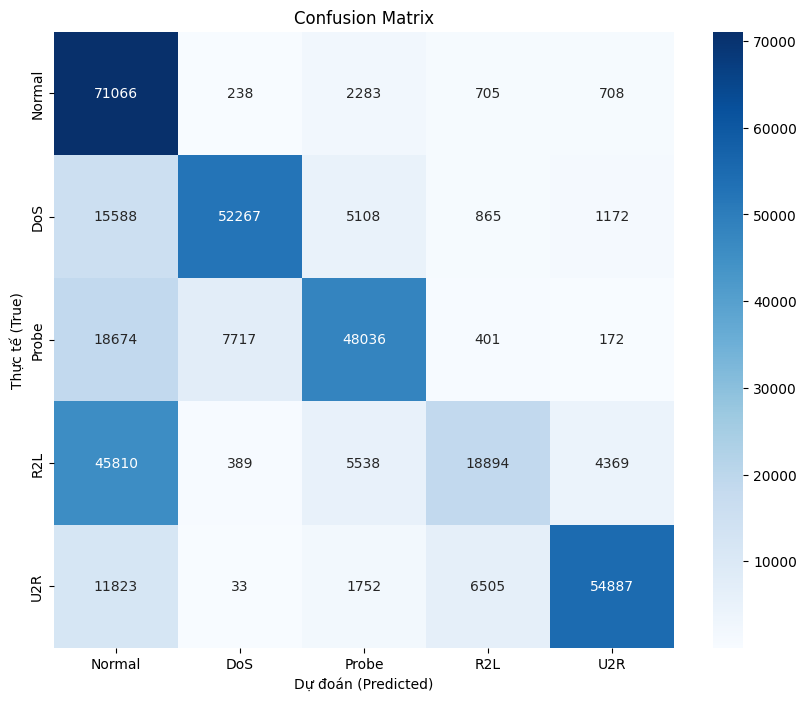


--- 🏁 RUN 3/5 | SEED: 9930 ---

 [PHASE 1] Pre-training Backbone với Triplet Loss...
   Epoch 1/5 | Triplet Loss: 0.2347
   Epoch 2/5 | Triplet Loss: 0.0233
   Epoch 3/5 | Triplet Loss: 0.0054
   Epoch 4/5 | Triplet Loss: 0.0113
   Epoch 5/5 | Triplet Loss: 0.0216

 [PHASE 2] Fine-tuning với Focal Loss & Euclidean Distance...
   Episode 500/5000 | Focal Loss: 12.602949
   Episode 1000/5000 | Focal Loss: 8.218254
   Episode 1500/5000 | Focal Loss: 5.984540
   Episode 2000/5000 | Focal Loss: 4.061625
   Episode 2500/5000 | Focal Loss: 7.652207
   Episode 3000/5000 | Focal Loss: 2.370167
   Episode 3500/5000 | Focal Loss: 5.729209
   Episode 4000/5000 | Focal Loss: 5.170108
   Episode 4500/5000 | Focal Loss: 4.508565
   Episode 5000/5000 | Focal Loss: 4.826083

📊 [Seed 9930 - Test+] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   22544 mẫu
------------------------------------------------------------
BÁO CÁO KẾT QUẢ: Seed 9930 - Test+
------------------------

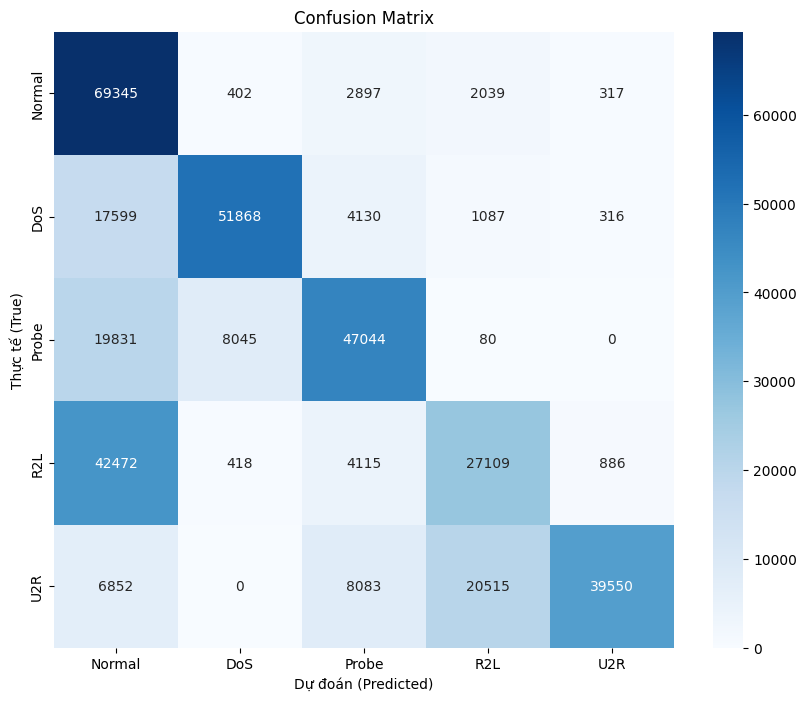


--- 🏁 RUN 4/5 | SEED: 2856 ---

 [PHASE 1] Pre-training Backbone với Triplet Loss...
   Epoch 1/5 | Triplet Loss: 0.2073
   Epoch 2/5 | Triplet Loss: 0.0331
   Epoch 3/5 | Triplet Loss: 0.0143
   Epoch 4/5 | Triplet Loss: 0.0133
   Epoch 5/5 | Triplet Loss: 0.0124

 [PHASE 2] Fine-tuning với Focal Loss & Euclidean Distance...
   Episode 500/5000 | Focal Loss: 6.812631
   Episode 1000/5000 | Focal Loss: 7.203245
   Episode 1500/5000 | Focal Loss: 3.160818
   Episode 2000/5000 | Focal Loss: 6.631087
   Episode 2500/5000 | Focal Loss: 2.597397
   Episode 3000/5000 | Focal Loss: 4.946543
   Episode 3500/5000 | Focal Loss: 4.957120
   Episode 4000/5000 | Focal Loss: 6.117909
   Episode 4500/5000 | Focal Loss: 1.645022
   Episode 5000/5000 | Focal Loss: 1.777177

📊 [Seed 2856 - Test+] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   22544 mẫu
------------------------------------------------------------
BÁO CÁO KẾT QUẢ: Seed 2856 - Test+
-------------------------

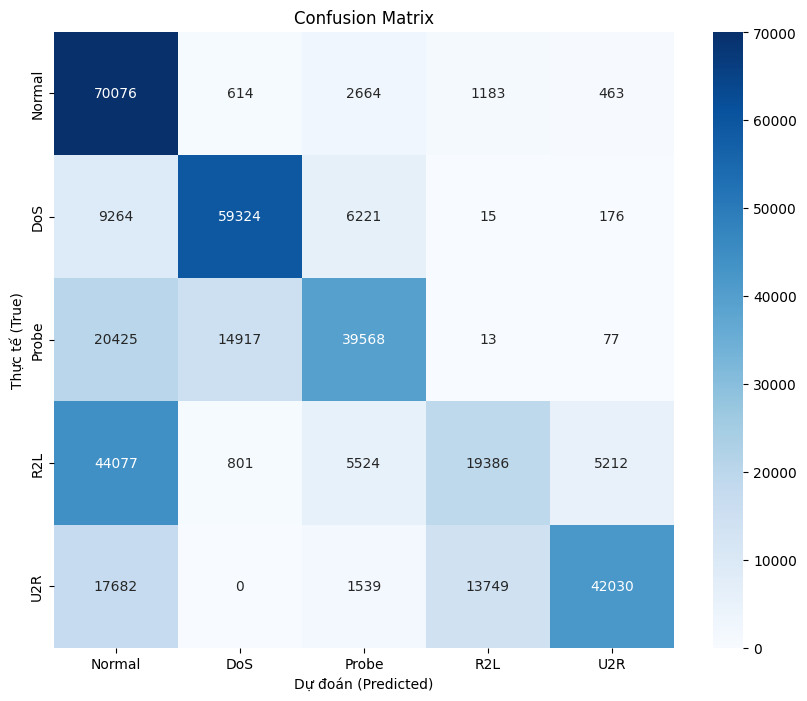


--- 🏁 RUN 5/5 | SEED: 4250 ---

 [PHASE 1] Pre-training Backbone với Triplet Loss...
   Epoch 1/5 | Triplet Loss: 0.2306
   Epoch 2/5 | Triplet Loss: 0.0276
   Epoch 3/5 | Triplet Loss: 0.0100
   Epoch 4/5 | Triplet Loss: 0.0153
   Epoch 5/5 | Triplet Loss: 0.0013

 [PHASE 2] Fine-tuning với Focal Loss & Euclidean Distance...
   Episode 500/5000 | Focal Loss: 10.026194
   Episode 1000/5000 | Focal Loss: 11.271677
   Episode 1500/5000 | Focal Loss: 11.730328
   Episode 2000/5000 | Focal Loss: 7.003085
   Episode 2500/5000 | Focal Loss: 9.391550
   Episode 3000/5000 | Focal Loss: 1.601146
   Episode 3500/5000 | Focal Loss: 4.898753
   Episode 4000/5000 | Focal Loss: 3.134110
   Episode 4500/5000 | Focal Loss: 2.795469
   Episode 5000/5000 | Focal Loss: 4.311903

📊 [Seed 4250 - Test+] Đang chạy 5000 episodes...
   ► Support (Học): 125973 mẫu
   ► Query (Thi):   22544 mẫu
------------------------------------------------------------
BÁO CÁO KẾT QUẢ: Seed 4250 - Test+
----------------------

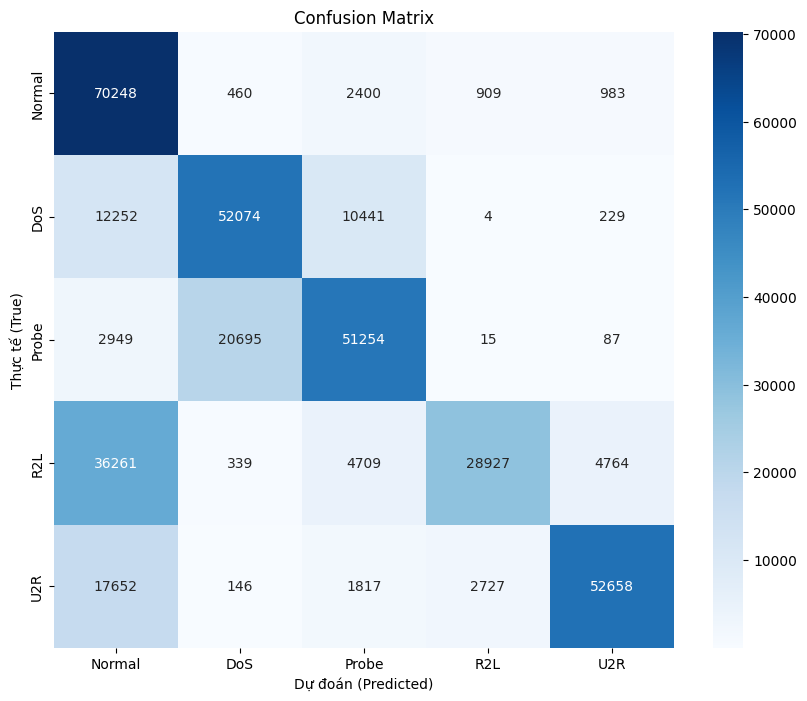


BÁO CÁO THỐNG KÊ 5-SEED (TEST+ SET)
Accuracy       : 0.6480 ± 0.0272
Normal_Recall  : 0.9313 ± 0.0130
DoS_Recall     : 0.7343 ± 0.0549
Probe_Recall   : 0.6179 ± 0.0572
R2L_Recall     : 0.3105 ± 0.0605
U2R_Recall     : 0.6459 ± 0.0946


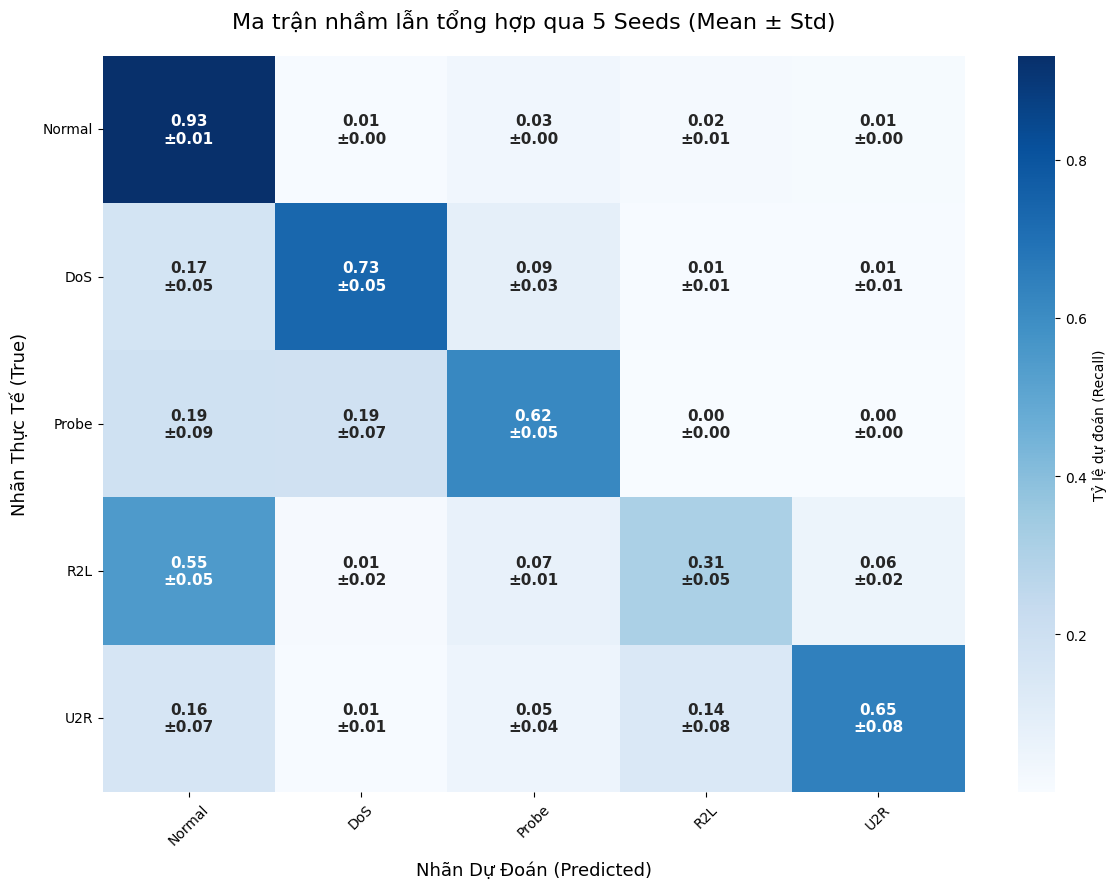

In [ ]:
# --- CẤU HÌNH ---
random_seeds = random.sample(range(1, 10000), 5)

class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
print(f"🎲 5 Seed ngẫu nhiên được chọn cho thí nghiệm: {random_seeds}")

all_results = []
all_cms = []

print(f"BẮT ĐẦU ĐÁNH GIÁ 5-SEED (5000 episodes/seed)...")

for i, seed in enumerate(random_seeds):
    print(f"\n--- 🏁 RUN {i+1}/5 | SEED: {seed} ---")
    seed_everything(seed)

    # Pre-train (Phase 1)
    backbone = DSC_CNN_NIDS().to(device)
    backbone = pretrain_backbone_triplet(X_train_imgs, y_train, epochs=5)

    # Fine-tune (Phase 2)
    final_model = train_finetune_loop(
        pretrained_model=backbone,
        X_input=X_train_imgs,
        y_input=y_train,
        n_episodes=5000,
        lr=0.00005,
        k_shot=20
    )

    # Đánh giá
    targets, preds = evaluate_dataset(
        final_model,
        train_ds, train_class_indices,
        test_ds, test_class_indices,
        n_episodes=N_EVAL_EPISODES, k_shot=K_SHOT,
        title=f"Seed {seed} - Test+"
    )

    # Lưu Confusion Matrix
    cm = confusion_matrix(targets, preds, normalize='true')
    all_cms.append(cm)

    # Lưu Metrics
    report = classification_report(targets, preds, target_names=class_names, output_dict=True)
    metrics = {
        'Accuracy': report['accuracy'],
        'Normal_Recall': report['Normal']['recall'],
        'DoS_Recall': report['DoS']['recall'],
        'Probe_Recall': report['Probe']['recall'],
        'R2L_Recall': report['R2L']['recall'],
        'U2R_Recall': report['U2R']['recall']
    }
    all_results.append(metrics)

# --- XỬ LÝ KẾT QUẢ TỔNG HỢP ---

df_results = pd.DataFrame(all_results)
mean_results = df_results.mean()
std_results = df_results.std()

# --- IN BÁO CÁO VÀ VẼ BIỂU ĐỒ ---

print("\n" + "="*50)
print("BÁO CÁO THỐNG KÊ 5-SEED (TEST+ SET)")
print("="*50)
for col in mean_results.index:
    print(f"{col:<15}: {mean_results[col]:.4f} ± {std_results[col]:.4f}")
print("="*50)

#---- Heatmap ----#
def plot_final_mean_std_cm(all_cms, class_names):
    all_cms_array = np.array(all_cms)
    mean_cm = np.mean(all_cms_array, axis=0)
    std_cm = np.std(all_cms_array, axis=0)

    plt.figure(figsize=(12, 9))

    annot = np.empty_like(mean_cm).astype(str)
    for i in range(mean_cm.shape[0]):
        for j in range(mean_cm.shape[1]):
            m = mean_cm[i, j]
            s = std_cm[i, j]
            annot[i, j] = f"{m:.2f}\n±{s:.2f}"

    ax = sns.heatmap(mean_cm, annot=annot, fmt="", cmap='Blues',
                     xticklabels=class_names, yticklabels=class_names,
                     annot_kws={"size": 11, "weight": "bold"},
                     cbar_kws={'label': 'Tỷ lệ dự đoán (Recall)'})

    plt.title("Ma trận nhầm lẫn tổng hợp qua 5 Seeds (Mean ± Std)", fontsize=16, pad=20)
    plt.xlabel("Nhãn Dự Đoán (Predicted)", fontsize=13, labelpad=10)
    plt.ylabel("Nhãn Thực Tế (True)", fontsize=13, labelpad=10)

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

plot_final_mean_std_cm(all_cms, class_names)